# Data fitting in Julia
## Fitting data to a user-defined function. 
Imports:

In [1]:
using LsqFit
using Distributions
using Plots
using Smoothing
using LaTeXStrings
using Measures
gr()

Plots.GRBackend()

Now define some nice plot defaults:

In [2]:
default(fontfamily = "Computer Modern", size=(800,500), titlefont = (16), legendfontsize = 10, 
        guidefont = (16, :darkgreen), tickfont = (12, :black), 
        framestyle = :box, yminorgrid = true, legend = :outertopright, dpi=600, margin = 5mm)

Our model will be a commonly occuring situation in physics:
a damped oscillator (common examples are a mass on a spring with
linear damping, the charge in an RLC circuit):

$$ m(t,p) = p_1 e^{-t/p_2} \cos(p_3 t + p_4) $$

In [3]:
model(t, p) = p[1] * exp.(-t./p[2]) .* cos.(p[3]*t .+ p[4]) 

model (generic function with 1 method)

In [4]:
tmin, tmax, N_times = 0.0, 10.0, 200
Δy = 0.08
dt = (tmax-tmin)/N_times
tdata = collect(LinRange(tmin,tmax,N_times))
δt = 0.1*dt*ones(length(tdata))
δy  = rand(Normal(0, Δy),length(tdata))
ydata = model(tdata, [2.0, 3.0, 2π, 0.0]) + δy
#initial guess for fit:
p0 = [1.0, 1.0, 2.0, 1.0];

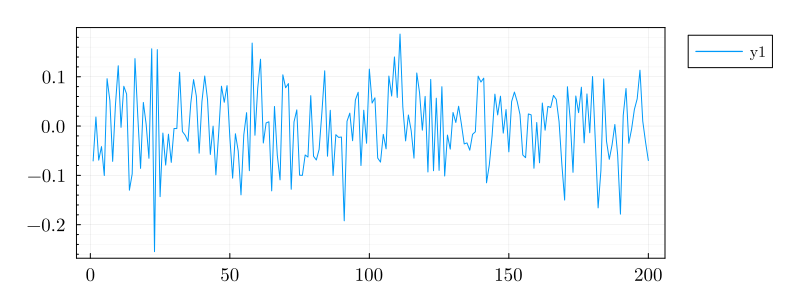

In [5]:
plot(δy, size=(800,300))

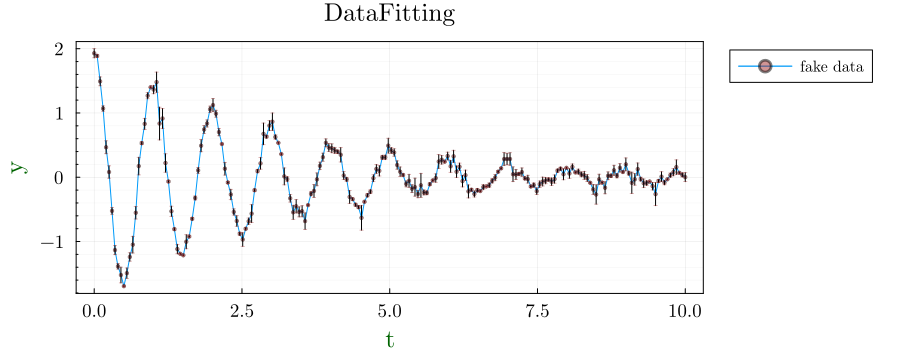

In [6]:
plot(tdata, ydata, xerr=δt, yerr=δy, marker=:circle, markersize=2, markeralpha=0.5,
     markercolor=:brown, label = "fake data", xlabel = "t", ylabel = "y", 
     title = "DataFitting", legend = :outertopright, dpi=600, size=(900,350))

Now, we have to find the fit parameters and the covariance matrix:

## fit the data and return fit params

In [7]:
function fit_data(model, tdata, ydata, p0)
    fit = curve_fit(model, tdata, ydata, p0)
    fit_params = fit.param
    σ = stderror(fit)
    return fit_params, σ # returns a tuple of fit parameters and their standard deviations
end

fit_data (generic function with 1 method)

In [8]:
p0, σ0 = fit_data(model, tdata, ydata, p0)
println(round.(p0; digits=4))
println(round.(σ0; digits=4))

[1.9707, 3.0705, 6.2843, 0.0049]
[0.0268, 0.0612, 0.0067, 0.0142]


## Model uncertainty via bootstrap method
I'll estimate the model uncertainty by the following method: <br>
1. Create a bootstrapped data set:<br> At each data sample time $t_i$, with data points $y(t_i)$,
choose a set of values $[y^{\prime}_1, y^{\prime}_2 \ldots, y^{\prime}_N]$ by  selecting a value  
from a Gaussian distribution of width $\Delta y_i$ centered each $y_i$.  <br>
2. Then compute the best fit parameters and repeat this a large number, $m_{\mathrm{samples}}$ of times. 
3. Compute the standard deviation of the best fit model values, and this give us the bootstrapped $1\sigma_B$ uncertainties on the model parameters. 

In [9]:
function bootstrap_fit(model, tdata, δt, Σt, ydata, δy, Σy, p0, m_samples)
    fit_params, σ = fit_data(model, tdata, ydata, p0)
    fit_params_array = zeros(length(fit_params), m_samples)
    
    for i in 1:m_samples
        t_boot = rand.(Normal.(tdata, abs.(Σt*δt))) # create bootstrap time data
        y_boot = rand.(Normal.(ydata, abs.(Σy*δy))) # create bootstrap y data
        fit_params_array[:,i] = fit_data(model, t_boot, y_boot, p0)[1]
    end
    p = vec(mean(fit_params_array, dims=2))
    σₚ =vec(std(fit_params_array, dims=2))
    return p, σₚ
end

bootstrap_fit (generic function with 1 method)

In [10]:
p0 = [1.0, 1.0, 2.0, 1.0];
p, σₚ = bootstrap_fit(model, tdata, δt, 1, ydata, δy,1, p0, 100)
println("p = ", round.(p; digits=4))
println("σₚ = ", round.(σₚ; digits=4))

p = [1.9677, 3.0788, 6.2853, 0.0022]
σₚ = [0.028, 0.0541, 0.0061, 0.0173]


In [11]:
p, σₚ = bootstrap_fit(model, tdata, δt, 1, ydata, δy,1, p0, 1000)
println("p = ", round.(p; digits=4))
println("σₚ = ", round.(σₚ; digits=4))

p = [1.9704, 3.0699, 6.2842, 0.005]
σₚ = [0.028, 0.061, 0.0068, 0.0176]


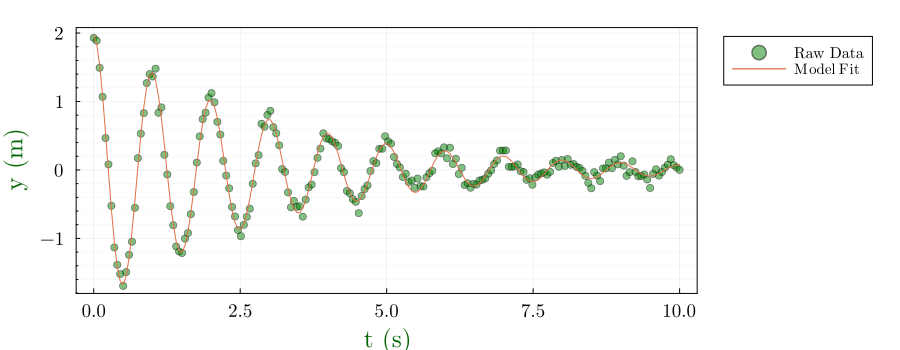

In [12]:

scatter(tdata, ydata, alpha=0.5, color=:green, label="Raw Data", size=(900,350),  xlabel = "t (s)", ylabel = "y (m)")
#plot!(tdata, Smoothing.binomial(ydata, 1), alpha=0.6, color=:darkred, label="Smoothed")
plot!(tdata,  model(tdata,p), label=L"$\mathrm{Model\;Fit}$")

    
        

## How to incorporate the fit parameter uncertainties
In order to plot the effect of the model parameter uncertainties as determined by the bootstrapped method, we need to know the uncertainties effect the model fit value.
This, in general, is not trivial, until you realize that the way to compute the largest possible value of the model, we need to only evaluate the partial derivative of the model with respect to the parameter of interest evaluate at the data point being considered. 

The model in this notebook is 
```julia
model(t, p) = p[1] * exp.(-t./p[2]) .* cos.(p[3]*t .+ p[4]) 
```

https://discourse.julialang.org/t/color-for-each-bar-in-a-bar-plot/68420



In [13]:
# numerical uncertainty for the model at time tᵢ computed using the partial derivative for the model with respect to the parameters. p,  at time tᵢ, and adding errors in quadrature.
function δy_at_tᵢ(model, tᵢ, p, σₚ, α=0.0001)
    Δ = α.*σₚ
    ∂pᵢ = zeros(length(p))
     p₊ = p .+ Δ
     p₋ = p .-  Δ
    ∂pᵢ = (model([tᵢ], p₊) .- model([tᵢ], p₋))/(2*Δ)
    dy = sqrt(sum(∂pᵢ.^2 .* σₚ.^2))
    return dy
end

δy_at_tᵢ (generic function with 2 methods)

The uncertainty in the model at each time $t_i$, $\Delta y(t\_i)$, can be obtained by adding the errors in quadrature; i.e.

$$ \Delta y(t_i) =  \sqrt{\sum_{j=1}^N \left(\frac{\partial y}{\partial p_j} \sigma_{p_j}\right)^2} $$

In [14]:
# uncertainty in the model function at each time point
function dy(model, t, p, σₚ; α=0.0001)
    i=1
    Δy = zeros(length(t))
    for  tᵢ in t    
        Δy[i] = δy_at_tᵢ(model, tᵢ, p, σₚ, α)
        i += 1
    end
    return  Δy
end

dy (generic function with 1 method)

In [15]:
p, σₚ = bootstrap_fit(model, tdata, δt, 1, ydata, δy,1, p0, 2000)
println("p = ", round.(p; digits=4))
println("σₚ = ", round.(σₚ; digits=4))

p = [1.9709, 3.0704, 6.278, 0.005]
σₚ = [0.0279, 0.0598, 0.2808, 0.018]


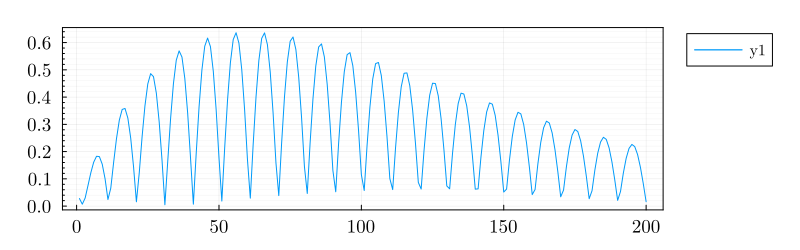

In [16]:
y_err = dy(model, tdata, p, σₚ; α=0.001);
plot(y_err, size=(800,250))

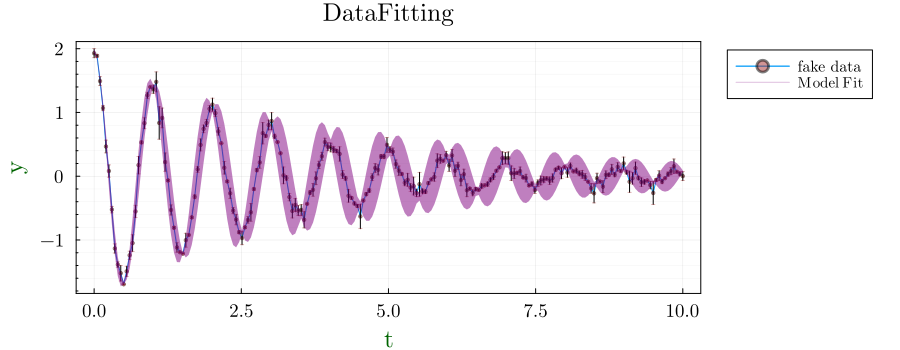

In [17]:

plot(tdata, ydata, xerr=δt, yerr=δy, marker=:circle, markersize=2, markeralpha=0.5,
     markercolor=:brown, label = "fake data", xlabel = "t", ylabel = "y", 
     title = "DataFitting", legend = :outertopright, dpi=600, size=(900,350))
#scatter(tdata, ydata, alpha=0.5, color=:green, label="Raw Data", size=(900,350),  xlabel = "t (s)", ylabel = "y (m)")
#plot!(tdata, Smoothing.binomial(ydata, 1), alpha=0.6, color=:darkred, label="Smoothed")
plot!(tdata,  model(tdata,p), ribbon=y_err, label=L"$\mathrm{Model\;Fit}$", color=:purple, alpha=0.2)

    